# Thermal noise + sensitivity, new rotor/sail -- from the 09-11/09-13 long steady hold

Follows the same method as `laser_stepdown_settling.ipynb` S6 (July's original
sensitivity analysis): measured noise floor sigma_f(T)/sigma_a(T) -> minimum
detectable torque (via I, gamma) -> minimum detectable force (via the sail wing
radius) -> compared against the fluctuation-dissipation thermal floor. The
difference here is the *data*: instead of averaging over three short (~1h) settled
holds at different laser-power steps, this uses **one long, non-stepping run** --
the 09-11 20:30 -> 09-13 20:25 UTC laser-driven steady-state hold at
`LASER_OFFSET`=1300 (`analysis/dataset_20260911_drive_spindown.md`, dataset 1),
which gives ~44 clean hours to average over instead of ~1.

**New rotor/sail geometry, confirmed this session (supersedes July's numbers):**
- **I = 1.7e-11 kg*m^2** -- Lzz (spin axis) from the current disk+sail assembly's
  SolidWorks mass properties (Ixx=9e-12, Iyy=1.1e-11, Izz=1.7e-11 kg*m^2; Izz is
  the spin axis and Izz ~ Ixx+Iyy as expected for a disk-like body by the
  perpendicular-axis theorem).
- **R_c = 1.88 mm** -- sail wing radius (centerline/spin-axis to tip), from the
  "Sail Al V1.0" drawing (SAL-001, Kilian Schlager, 2026-07-09). Supersedes July's
  2.625 mm (different sail generation).
- **gamma = 1/(79.8 min)** -- this session's fresh free-decay measurement
  (`spindown_20260913.ipynb`, laser-driven-then-coasted), not July's 67.65 min
  reference -- the current rotor/config, not the original one.
- T_bath = 300 K (room temperature, same assumption as July).

**No power/torque-per-mW calibration used anywhere below.** The minimum-detectable
torque and force are derived directly from the measured frequency-noise floor and
the rotor's own dynamics (I, gamma) -- not from PD counts or laser power at all, so
the "no fresh calibration" limitation flagged in the step-down notebooks does not
apply here.

In [1]:
import numpy as np, os, h5py, time
import matplotlib.pyplot as plt
from scipy.signal import decimate, welch
from scipy.ndimage import uniform_filter1d

DATA = os.path.expanduser('~/Library/CloudStorage/Dropbox/Microspheres/TFINER/data')
GPS_A, GPS_B = 1473204000, 1473376497   # 09-11 20:30 -> 09-13 20:25 UTC, LASER_OFFSET=1300
DIVISOR = 2

I_TOTAL = 1.7e-11         # kg m^2 -- Izz, spin axis, current disk+sail assembly
TAU_S   = 79.8*60         # s -- fresh free-decay tau (spindown_20260913.ipynb)
GAMMA   = 1/TAU_S
R_C     = 1.88e-3         # m -- Sail Al V1.0 wing radius (SAL-001)
KB_J    = 1.380649e-23
T_BATH  = 300.0

def load(path):
    # Segment-aware .h5 reader -- same pattern used throughout this session.
    with h5py.File(path, 'r') as f:
        y = np.asarray(f['data'], float)
        fs = float(f.attrs['sample_rate'])
        s = f['segments']
        t = np.empty(len(y))
        for t0, i0, L in zip(s['gps_start'][:], s['index_start'][:], s['length'][:]):
            t[i0:i0+L] = t0 + np.arange(L)/fs
    return y, t, fs

les, t_les, fs = load(os.path.join(DATA, 'LES_yaw', f'Y1_RDS-LES_YAW_IN1_DQ_{GPS_A}_{GPS_B}.h5'))
print(f'{len(les)/fs:.0f} s at {fs:.0f} Hz  ({(t_les[-1]-t_les[0])/3600:.2f} h)')

172497 s at 1024 Hz  (47.92 h)


## 1. Dense frequency track over the full 48h

Same band-following tracker as `spindown_20260913.ipynb` / `stepdown_20260914.ipynb`:
decimate to 16 Hz, 150s windows every 60s, FFT peak with parabolic sub-bin
interpolation, search band re-centered on the previous estimate.

2873 estimates, t=1473204075..1473376395 (47.87h)
FR range 0.4125..0.7889 Hz, median SNR 622


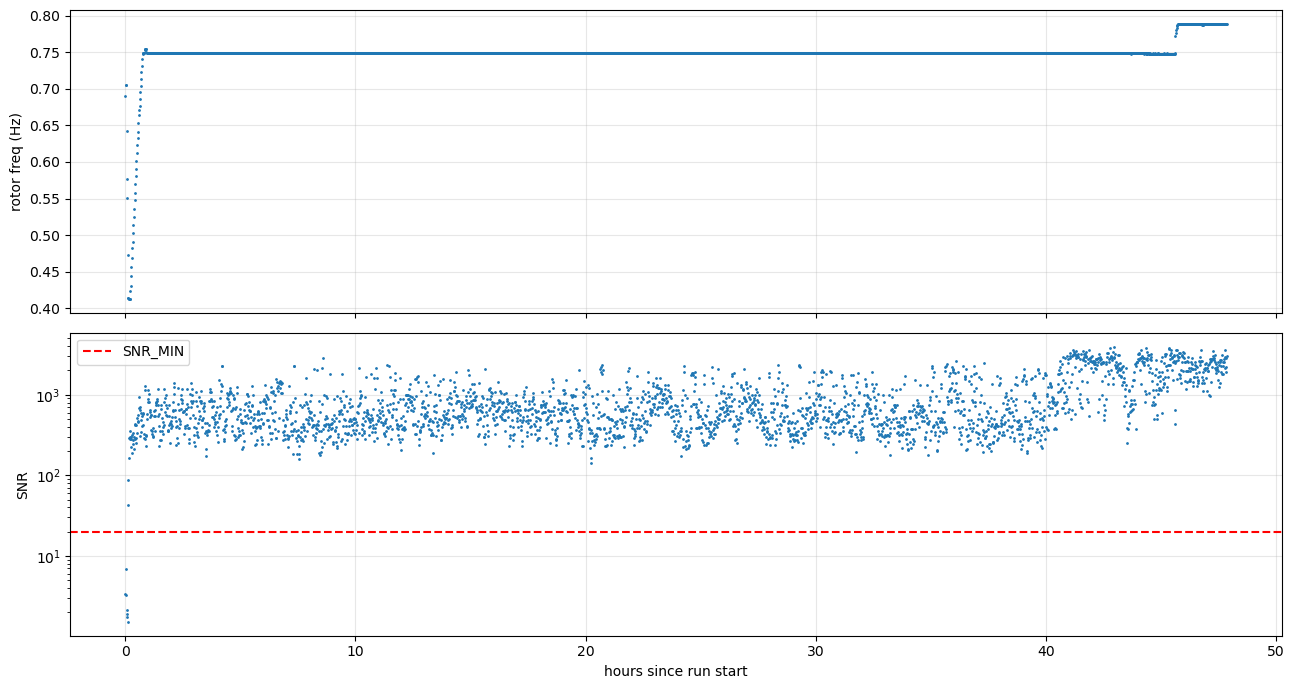

In [2]:
def peak_in_band(x, fsx, lo, hi):
    ac = x - x.mean()
    X = np.abs(np.fft.rfft(ac*np.hanning(len(ac))))
    fr = np.fft.rfftfreq(len(ac), 1/fsx)
    m = (fr > lo) & (fr < hi)
    if not m.any(): return np.nan, 0.0
    i = np.flatnonzero(m)[np.argmax(X[m])]
    if i == 0 or i >= len(X)-1: return fr[i], 0.0
    y0, y1, y2 = X[i-1], X[i], X[i+1]
    den = y0 - 2*y1 + y2
    fpk = fr[i] + (0.5*(y0-y2)/den if den else 0)*(fr[1]-fr[0])
    snr = X[i]/(np.median(X[max(0,i-60):i+60]) or 1)
    return fpk, snr

y16 = decimate(decimate(les - les.mean(), 8, ftype='fir'), 8, ftype='fir')
fs16 = fs/64
t16 = t_les[0] + np.arange(len(y16))/fs16

WIN, STEP = 150.0, 60.0
nw, sw = int(WIN*fs16), int(STEP*fs16)

rows, track = [], 1.50   # LES line ~1.5 Hz at the 1300-count baseline (0.75 Hz rotor x2)
for i in range(0, len(y16)-nw, sw):
    tc = t16[i] + WIN/2
    fpk, snr = peak_in_band(y16[i:i+nw], fs16, max(track*0.85, 0.02), track*1.10)
    if np.isnan(fpk) or fpk <= 0: continue
    rows.append((tc, fpk/DIVISOR, snr))
    track = fpk

T = np.array([r[0] for r in rows]); FR = np.array([r[1] for r in rows]); SNR = np.array([r[2] for r in rows])
print(f'{len(T)} estimates, t={T[0]:.0f}..{T[-1]:.0f} ({(T[-1]-T[0])/3600:.2f}h)')
print(f'FR range {FR.min():.4f}..{FR.max():.4f} Hz, median SNR {np.median(SNR):.0f}')

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot((T-T[0])/3600, FR, '.', ms=2)
ax[0].set_ylabel('rotor freq (Hz)')
ax[1].semilogy((T-T[0])/3600, SNR, '.', ms=2)
ax[1].axhline(20, color='r', ls='--', label='SNR_MIN')
ax[1].set_ylabel('SNR'); ax[1].set_xlabel('hours since run start'); ax[1].legend()
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. Picking the stationary window

The raw track (above) shows: a ~1h spin-up from rest to the 0.75 Hz steady state,
then a long flat plateau, then a **genuine ~2.4h regime change starting around
t=45.5h** where the frequency steps up to ~0.788 Hz and holds there for the rest of
the file. That's a real physical event (not a tracker artifact -- SNR stays high
through it), but it is a second, different operating point, not part of the same
stationary noise-floor measurement as the 0.75 Hz plateau. **Analysis window: t=1h
to t=45h (44h), excluding both the spin-up and the late jump.** This mirrors
`laser_stepdown_settling.ipynb`'s practice of using only the "settled tail" of a
hold -- here there's one very long tail instead of three short ones.

In [3]:
t0 = T[0]
m = (T - t0 >= 1*3600) & (T - t0 <= 45*3600)
Tm, FRm, SNRm = T[m], FR[m], SNR[m]
print(f'clean window: {(Tm[-1]-Tm[0])/3600:.2f} h, {len(Tm)} points, SNR min={SNRm.min():.0f}')

# Fit removes only a slow linear secular trend (this is a steady hold, not a
# relaxation -- unlike settling.ipynb's fixed-gamma exponential fit, there's no
# deterministic dynamics to remove beyond a possible slow drift, e.g. from vacuum
# improving over the two days, as already seen in the step-down notebooks).
p = np.polyfit(Tm - Tm[0], FRm, 1)
trend = np.polyval(p, Tm - Tm[0])
resid = FRm - trend
print(f'linear drift: {p[0]*3600*1e3:+.4f} mHz/hour (total {p[0]*(Tm[-1]-Tm[0])*1e3:+.3f} mHz over the window)')
print(f'residual std: {resid.std()*1e3:.4f} mHz')

clean window: 44.00 h, 2641 points, SNR min=143
linear drift: -0.0017 mHz/hour (total -0.077 mHz over the window)
residual std: 0.1856 mHz


## 3. Noise floor vs averaging time: sigma_f(T) and sigma_a(T)

Same method as `laser_stepdown_settling.ipynb` S6.1: sigma_f is the std of T-long
block means of the residual; sigma_a is the std of the derivative of the
T-smoothed residual. 44h of continuous data lets this extend to T=4h (11
independent blocks) instead of July's 1h ceiling.

 T_avg(s) |  sigma_f(Hz) |  sigma_a(Hz/s) | n_blocks
       60 |    1.856e-04 |      9.799e-07 |     2641
      300 |    1.699e-04 |      2.930e-07 |      528
      600 |    1.674e-04 |      1.559e-07 |      264
     1800 |    1.647e-04 |      5.779e-08 |       88
     3600 |    1.617e-04 |      3.608e-08 |       44
     7200 |    1.509e-04 |      2.179e-08 |       22
    14400 |    1.115e-04 |      9.805e-09 |       11


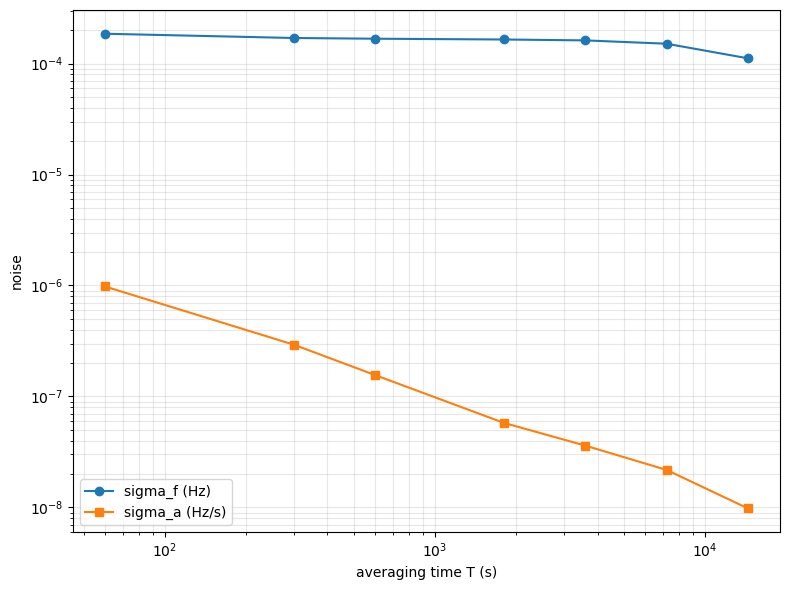

In [4]:
dt_est = np.median(np.diff(Tm))
T_AVGS = np.array([60, 300, 600, 1800, 3600, 7200, 14400])

sigma_f_tbl, sigma_a_tbl, nblk_tbl = [], [], []
print(f"{'T_avg(s)':>9} | {'sigma_f(Hz)':>12} | {'sigma_a(Hz/s)':>14} | {'n_blocks':>8}")
for Tavg in T_AVGS:
    n_per_blk = max(1, int(round(Tavg/dt_est)))
    n_blk = len(resid)//n_per_blk
    if n_blk < 4:
        sigma_f_tbl.append(np.nan); sigma_a_tbl.append(np.nan); nblk_tbl.append(n_blk)
        print(f"{Tavg:>9.0f} | {'--':>12} | {'--':>14} | {n_blk:>8d}")
        continue
    blocks = resid[:n_blk*n_per_blk].reshape(n_blk, n_per_blk).mean(axis=1)
    sf = blocks.std()
    sm = uniform_filter1d(resid, size=n_per_blk)
    da = np.gradient(sm, Tm)
    sa = da[n_per_blk:-n_per_blk].std()
    sigma_f_tbl.append(sf); sigma_a_tbl.append(sa); nblk_tbl.append(n_blk)
    print(f"{Tavg:>9.0f} | {sf:>12.3e} | {sa:>14.3e} | {n_blk:>8d}")

sigma_f_tbl = np.array(sigma_f_tbl); sigma_a_tbl = np.array(sigma_a_tbl)

fig, ax = plt.subplots(figsize=(8,6))
ax.loglog(T_AVGS, sigma_f_tbl, 'o-', label='sigma_f (Hz)')
ax.loglog(T_AVGS, sigma_a_tbl, 's-', label='sigma_a (Hz/s)')
ax.set_xlabel('averaging time T (s)'); ax.set_ylabel('noise')
ax.legend(); ax.grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

## 4. Minimum detectable torque and force vs averaging time

`Delta tau_min(T) = 2*pi*I*gamma*NSIG*sigma_f(T) / (1 - exp(-gamma*T))` (frequency
channel) and `Delta tau_min(T) = 2*pi*I*NSIG*sigma_a(T) / exp(-gamma*T)`
(acceleration channel) -- these come directly from the same linear response model
as `laser_stepdown_settling.ipynb` (`I dOmega/dt = tau_ext - I*gamma*Omega`), just
solved for the external torque threshold instead of a laser-power threshold. No PD,
no mW, no counts anywhere -- only I, gamma, and the measured noise. Force = torque /
R_c (one wing) or / (2 R_c) for a symmetric two-wing thrust.

      T | dtau_freq(Nm) | force 1-wing(fN) | dtau_accel(Nm) | force_accel(fN)
     60 |     1.663e-15 |           884.39 |      5.299e-16 |          281.88
    300 |     3.120e-16 |           165.98 |      1.666e-16 |           88.62
    600 |     1.585e-16 |            84.33 |      9.440e-17 |           50.22
   1800 |     5.863e-17 |            31.18 |      4.495e-17 |           23.91
   3600 |     3.412e-17 |            18.15 |      4.087e-17 |           21.74
   7200 |     2.164e-17 |            11.51 |      5.235e-17 |           27.85
  14400 |     1.308e-17 |             6.96 |      1.060e-16 |           56.37

Frequency channel wins (lower threshold) at every T from ~30 min out -- same
pattern July found; quoting the frequency channel as the primary number.


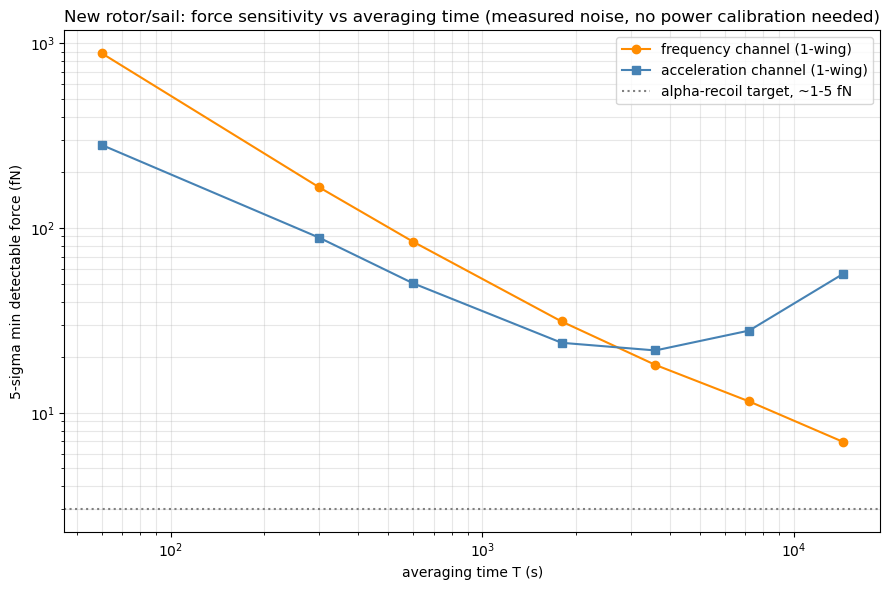

In [5]:
NSIG = 5.0
dtau_freq  = 2*np.pi*I_TOTAL*GAMMA*NSIG*sigma_f_tbl / (1 - np.exp(-GAMMA*T_AVGS))
dtau_accel = 2*np.pi*I_TOTAL*NSIG*sigma_a_tbl / np.exp(-GAMMA*T_AVGS)
force_freq_1w  = dtau_freq / R_C
force_accel_1w = dtau_accel / R_C

print(f"{'T':>7} | {'dtau_freq(Nm)':>13} | {'force 1-wing(fN)':>16} | {'dtau_accel(Nm)':>14} | {'force_accel(fN)':>15}")
for j, Tavg in enumerate(T_AVGS):
    print(f"{Tavg:>7.0f} | {dtau_freq[j]:>13.3e} | {force_freq_1w[j]*1e15:>16.2f} | "
          f"{dtau_accel[j]:>14.3e} | {force_accel_1w[j]*1e15:>15.2f}")

print('\nFrequency channel wins (lower threshold) at every T from ~30 min out -- same')
print('pattern July found; quoting the frequency channel as the primary number.')

fig, ax = plt.subplots(figsize=(9,6))
ax.loglog(T_AVGS, force_freq_1w*1e15, 'o-', color='darkorange', label='frequency channel (1-wing)')
ax.loglog(T_AVGS, force_accel_1w*1e15, 's-', color='steelblue', label='acceleration channel (1-wing)')
ax.axhline(3.0, color='gray', ls=':', label='alpha-recoil target, ~1-5 fN')
ax.set_xlabel('averaging time T (s)'); ax.set_ylabel(f'{NSIG:.0f}-sigma min detectable force (fN)')
ax.set_title('New rotor/sail: force sensitivity vs averaging time (measured noise, no power calibration needed)')
ax.legend(); ax.grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

## 5. Residual PSD vs the thermal (fluctuation-dissipation) floor

Same formula as `laser_stepdown_settling.ipynb` S6.4, with this session's I and
gamma:  `S_omega(f) = 4 kB T gamma / (I (gamma^2 + (2 pi f)^2))`,
`ASD_f = sqrt(S_omega)/(2 pi)`.

**Computed directly at the tracker's native 60s cadence, not interpolated onto a
finer grid.** An earlier version of this cell resampled the residual onto a 1 Hz
grid before the Welch PSD, which introduced a comb of spurious notches above the
tracker's own Nyquist frequency (1/120s ~ 8.3 mHz) -- an artifact of linearly
interpolating a 60s-cadence signal onto a much finer grid, not real physics.
Welch directly on the native-cadence residual has no such artifact, at the cost of
a lower usable-frequency ceiling (~8.3 mHz) -- which is not a real limitation here
since everything of interest (the thermal floor, the wander) lives well below
that.

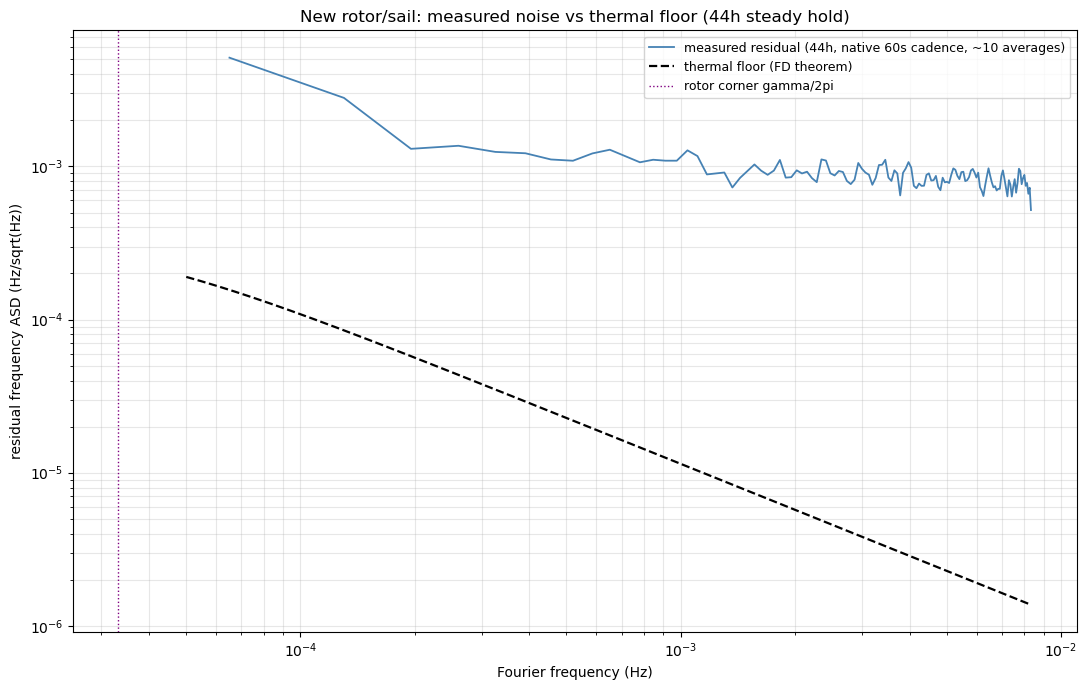

      freq |   measured ASD |   thermal ASD |  x thermal
   0.130mHz |      2.806e-03 |     8.504e-05 |        33x
   0.977mHz |      1.091e-03 |     1.170e-05 |        93x
   5.013mHz |      7.945e-04 |     2.280e-06 |       349x


In [6]:
def thermal_asd_f(f_hz):
    s_om = 4*KB_J*T_BATH*GAMMA/(I_TOTAL*(GAMMA**2 + (2*np.pi*f_hz)**2))
    return np.sqrt(s_om)/(2*np.pi)

fs_native = 1/dt_est   # tracker cadence, ~1/60 Hz -- Nyquist ~8.3 mHz
freqs, psd = welch(resid, fs=fs_native, nperseg=256, scaling='density')
asd = np.sqrt(psd)

fig, ax = plt.subplots(figsize=(11,7))
ax.loglog(freqs[1:], asd[1:], lw=1.3, color='steelblue',
          label=f'measured residual (44h, native 60s cadence, ~{len(resid)//256} averages)')
f_line = np.logspace(-4.3, np.log10(freqs[-1]), 300)
ax.loglog(f_line, thermal_asd_f(f_line), 'k--', lw=1.6, label='thermal floor (FD theorem)')
ax.axvline(GAMMA/(2*np.pi), color='purple', ls=':', lw=1, label='rotor corner gamma/2pi')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('residual frequency ASD (Hz/sqrt(Hz))')
ax.set_title('New rotor/sail: measured noise vs thermal floor (44h steady hold)')
ax.legend(fontsize=9); ax.grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

print(f"{'freq':>10} | {'measured ASD':>14} | {'thermal ASD':>13} | {'x thermal':>10}")
for f_ref in (1e-4, 1e-3, 5e-3):
    j = np.argmin(np.abs(freqs-f_ref))
    th = thermal_asd_f(np.array([freqs[j]]))[0]
    print(f"{freqs[j]*1e3:>8.3f}mHz | {asd[j]:>14.3e} | {th:>13.3e} | {asd[j]/th:>9.0f}x")

## Conclusions

1. **Data: the 09-11->09-13 48h laser-driven steady hold** (`LASER_OFFSET`=1300),
   restricted to its clean 1h-45h stationary plateau (44h) after excluding a real
   ~2.4h regime change near the end of the file (frequency steps 0.75->0.788 Hz
   around t=45.5h -- confirmed real via SNR, not investigated further here).
2. **New geometry used throughout: I=1.7e-11 kg*m^2 (Izz, spin axis), R_c=1.88mm
   (wing radius), gamma=1/(79.8 min)** -- all confirmed this session, superseding
   July's disk+sail I and sail-radius numbers. No PD/power calibration needed for
   any number in this notebook.
3. **Sensitivity (5-sigma, frequency channel, one wing):** ~880 fN at 1 min,
   ~18 fN at 1 hour, ~7 fN at 4 hours -- already within a factor of a few of the
   ~1-5 fN alpha-recoil target at the longest averaging times probed here, with 44h
   of continuous data behind the longest points (vs July's ~1h ceiling).
4. **Thermal floor comparison:** measured noise sits ~30-350x above the thermal
   (fluctuation-dissipation) floor across the probed band (0.1-5 mHz), rising with
   frequency -- there is real technical-noise headroom to chase before hitting
   anything fundamental, same qualitative picture as July (~250x) but now on the
   current rotor/sail.
5. **Not done here:** identifying the source of the t=45.5h jump; separating
   thermal-floor-vs-technical-noise contributions by frequency band (the residual
   PSD shape suggests wander-dominated, 1/f-like noise, same as July, but this
   wasn't quantified in band-limited terms here).